# 📥 src/etl/extract.py — Interactive Walkthrough

**Project:** Nigeria Disease Surveillance Dashboard  
**Module:** `src/etl/extract.py`  
**Purpose:** Walk through every extractor function interactively,  
inspect the raw output of each source, and understand the data  
before any cleaning is applied.

---
**Functions covered:**

| Function | Source | Output |
|----------|--------|--------|
| `extract_ncdc_pdfs()` | NCDC Nigeria PDF sitreps | Raw disease tables |
| `extract_who_data()` | WHO AFRO CSV/Excel | Cross-validation data |
| `extract_nasa_rainfall()` | NASA POWER REST API | Monthly precipitation |
| `extract_health_facilities()` | HDX Nigeria CSV | Facility locations |
| `extract_population()` | NBS / WorldPop Excel | State populations |
| `extract_shapefiles()` | GRID3 Nigeria .shp | State boundaries |

---
> **Rule:** Extractors do **no cleaning**. They return data exactly as  
> found in the source. Cleaning is handled in `transform.py`.

## 1. Environment Setup

In [1]:
import sys
import time
import warnings
from pathlib import Path

import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

# Add project root to path so we can import src modules
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import Paths, Diseases, settings
from src.utils.logger import get_logger, set_log_level
from src.utils.state_maps import STATE_CENTROIDS

# Show INFO logs so we can see what each extractor is doing
set_log_level('INFO')
logger = get_logger('extract_notebook')

# Make sure data directories exist
Paths.ensure_all()

print('✅ Environment ready')
print(f'   Project root  : {PROJECT_ROOT}')
print(f'   Raw data dir  : {Paths.raw}')
print(f'   Shapefiles dir: {Paths.shapefiles}')
print(f'   Diseases      : {Diseases.all}')

✅ Environment ready
   Project root  : C:\Users\Hp\Documents\nigeria-disease-surveillance
   Raw data dir  : C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw
   Shapefiles dir: C:\Users\Hp\Documents\nigeria-disease-surveillance\data\shapefiles
   Diseases      : ['Cholera', 'Lassa Fever', 'Mpox', 'Meningitis', 'Yellow Fever']


## 2. Internal Helpers — `_save_raw()` and `_load_cached()`

These two private functions are used internally by every extractor.

- **`_save_raw(df, filename)`** — saves any DataFrame to `data/raw/` as CSV.  
  Called at the end of every extractor so results are cached on disk.
- **`_load_cached(filename)`** — checks whether a cached version already  
  exists in `data/raw/` and returns it, skipping a slow re-download.

This caching pattern means you only pay the download cost once.  
Pass `force_download=True` to any extractor to bypass the cache.

In [2]:
# Import the internal helpers to inspect them
from src.etl.extract import _save_raw, _load_cached

# Demonstrate _save_raw with a tiny test DataFrame
test_df = pd.DataFrame({
    'state':   ['Lagos', 'Kano'],
    'cases':   [100, 80],
    'disease': ['Cholera', 'Cholera'],
})

saved_path = _save_raw(test_df, '_notebook_test.csv')
print(f'_save_raw() → {saved_path}')
print(f'File exists: {saved_path.exists()}')

# Demonstrate _load_cached
loaded = _load_cached('_notebook_test.csv')
print(f'\n_load_cached() → {type(loaded).__name__} with {len(loaded)} rows')
print(loaded)

# Clean up test file
saved_path.unlink()
print('\n✅ Helpers work correctly — test file cleaned up')

_save_raw() → C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw\_notebook_test.csv
File exists: True

_load_cached() → DataFrame with 2 rows
   state  cases  disease
0  Lagos    100  Cholera
1   Kano     80  Cholera

✅ Helpers work correctly — test file cleaned up


## 3. `extract_ncdc_pdfs()` — NCDC Situation Report PDFs

### What it does
Opens every PDF in a disease folder, runs the structured disease-specific
parser (pdfplumber tables + word-position + OCR + text fallbacks),
and concatenates results into one raw DataFrame.

### Key design decisions
- **Provenance columns** (`_source_file`, `_data_type`) are added to every
  row — `_source_file` names the source PDF; `_data_type` labels the
  extraction strategy used (e.g. `current_week`, `current_highlights`,
  `national_cumulative`).
- **No column renaming here** — column names vary across years.
  `transform.py` handles that.
- **Bad PDFs don't crash the pipeline** — individual PDF failures are
  logged and skipped; the remaining PDFs continue processing.

### Before running
Download NCDC sitreps from [ncdc.gov.ng/diseases/sitreps](https://ncdc.gov.ng/diseases/sitreps)  
and place them in:
```
data/raw/ncdc_pdfs/cholera/
data/raw/ncdc_pdfs/lassa_fever/
data/raw/ncdc_pdfs/mpox/
data/raw/ncdc_pdfs/meningitis/
data/raw/ncdc_pdfs/yellow_fever/
```

In [3]:
from src.etl.extract import extract_ncdc_pdfs, _extract_single_pdf

raw_ncdc = {}

for disease_name, folder_key in Diseases.pdf_folder_map.items():
    folder = Paths.raw / 'ncdc_pdfs' / folder_key
    print(f'\n── {disease_name} ──────────────────────────────')
    print(f'   Folder: {folder}')
    print(f'   PDFs found: {len(list(folder.glob("*.pdf"))) if folder.exists() else 0}')

    df = extract_ncdc_pdfs(folder, disease_name)

    if df.empty:
        print(f'   ⚠️  No data extracted — place NCDC PDFs in the folder above')
    else:
        raw_ncdc[disease_name] = df
        print(f'   ✅ {len(df):,} rows extracted')
        print(f'   Columns : {list(df.columns)}')
        print(f'   Sources : {df["_source_file"].nunique()} unique PDFs')
        # Show the first few raw rows — expect messiness
        display(df.head(3))

print(f'\n📊 Summary: {len(raw_ncdc)}/{len(Diseases.all)} diseases extracted')


── Cholera ──────────────────────────────
   Folder: C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw\ncdc_pdfs\cholera
   PDFs found: 49
2026-06-08 15:10:58 | INFO     | src.etl.extract | NCDC Cholera: loaded 1089 rows from cache


   ✅ 1,089 rows extracted
   Columns : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type']
   Sources : 49 unique PDFs


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type
0,Borno,Cholera,52,2022,6,0,0,NaN,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week
1,Yobe,Cholera,52,2022,0,0,0,NaN,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week
2,Katsina,Cholera,52,2022,1,0,0,NaN,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week



── Lassa Fever ──────────────────────────────
   Folder: C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw\ncdc_pdfs\lassa_fever
   PDFs found: 155
2026-06-08 15:10:58 | INFO     | src.etl.extract | NCDC Lassa Fever: loaded 4040 rows from cache
   ✅ 4,040 rows extracted
   Columns : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type', '_note']
   Sources : 155 unique PDFs


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type,_note
0,Edo,Lassa Fever,1,2023,38,3,0,NaN,1b40aecdc7a9100797389299b2519a38.pdf,current_week,NaN
1,Bauchi,Lassa Fever,1,2023,7,3,2,NaN,1b40aecdc7a9100797389299b2519a38.pdf,current_week,NaN
2,Taraba,Lassa Fever,1,2023,2,0,0,NaN,1b40aecdc7a9100797389299b2519a38.pdf,current_week,NaN


...


── Meningitis ──────────────────────────────
   Folder: C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw\ncdc_pdfs\meningitis
   PDFs found: 11
2026-06-08 15:10:59 | INFO     | src.etl.extract | NCDC Meningitis: loaded 201 rows from cache
   ✅ 201 rows extracted
   Columns : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type']
   Sources : 11 unique PDFs


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type
0,Jigawa,Meningitis,29,2023,3,0,0,0.0,519e5ccfcc5d808281ba57e9d4597352.pdf,current_week_highlights
1,Gombe,Meningitis,29,2023,2,0,0,0.0,519e5ccfcc5d808281ba57e9d4597352.pdf,current_week_highlights
2,Bayelsa,Meningitis,47,2023,0,0,0,NaN,An Update of Meningitis Outbreak in Nigeria_16...,current_week



── Yellow Fever ──────────────────────────────
   Folder: C:\Users\Hp\Documents\nigeria-disease-surveillance\data\raw\ncdc_pdfs\yellow_fever
   PDFs found: 27
2026-06-08 15:10:59 | INFO     | src.etl.extract | NCDC Yellow Fever: loaded 772 rows from cache
   ✅ 772 rows extracted
   Columns : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type']
   Sources : 27 unique PDFs


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type
0,Akwa Ibom,Yellow Fever,18,2023,1,0,0,NaN,1f1c39c3c68eacf284bddcd5d8d7f5eb.pdf,current_highlights
1,Anambra,Yellow Fever,18,2023,5,0,0,NaN,1f1c39c3c68eacf284bddcd5d8d7f5eb.pdf,current_highlights
2,Bauchi,Yellow Fever,18,2023,38,0,0,NaN,1f1c39c3c68eacf284bddcd5d8d7f5eb.pdf,current_highlights



📊 Summary: 5/5 diseases extracted


### 3.1 Inspect a single PDF

Use `_extract_single_pdf()` to inspect one specific file.  
This is useful for debugging a PDF that produced unexpected output.

In [4]:
# Point this at any single NCDC PDF on your disk
sample_pdf = next(
    (Paths.raw / 'ncdc_pdfs' / 'cholera').glob('*.pdf'),
    None
)

if sample_pdf:
    print(f'Inspecting: {sample_pdf.name}')
    single_result = _extract_single_pdf(sample_pdf, 'Cholera')
    print(f'  Rows extracted : {len(single_result):,}')
    print(f'  Columns        : {list(single_result.columns)}')
    print(f'  Data types     : {single_result["_data_type"].unique()}')
    display(single_result.head(5))
else:
    print('⚠️  No cholera PDFs found. Place PDFs in data/raw/ncdc_pdfs/cholera/')

Inspecting: 114c6e786ac78f09d484f070d72f2f0c.pdf
2026-06-08 15:11:33 | INFO     | src.etl.pdf_parsers | Cholera: word-position extracted 28 rows from page 7 in 114c6e786ac78f09d484f070d72f2f0c.pdf
  Rows extracted : 28
  Columns        : ['state', 'disease', 'epi_week', 'year', 'suspected_cases', 'confirmed_cases', 'deaths', 'cfr_pct', '_source_file', '_data_type']
  Data types     : <ArrowStringArray>
['current_week']
Length: 1, dtype: str


,state,disease,epi_week,year,suspected_cases,confirmed_cases,deaths,cfr_pct,_source_file,_data_type
0,Borno,Cholera,52,2022,6,0,0,None,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week
1,Yobe,Cholera,52,2022,0,0,0,None,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week
2,Katsina,Cholera,52,2022,1,0,0,None,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week
3,Taraba,Cholera,52,2022,11,0,0,None,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week
4,Kano,Cholera,52,2022,0,0,0,None,114c6e786ac78f09d484f070d72f2f0c.pdf,current_week


## 4. `extract_who_data()` — WHO Annual Data (Cross-validation)

### What it does
Fetches annual Nigeria disease totals from the **WHO Global Health Observatory
(GHO) OData API** — no login, no manual download required.

If you have placed local files in `data/raw/who/` those take priority;
otherwise the function calls the API automatically and caches the result
as `data/raw/who_raw.csv`.

### Diseases covered
| Disease | Indicator (cases) | Indicator (deaths) |
|---------|------------------|--------------------|
| Cholera | `CHOLERA_0000000001` | `CHOLERA_0000000002` |

### Output schema
| Column | Description |
|--------|-------------|
| `year` | Calendar year |
| `disease` | Disease name |
| `reported_cases` | WHO reported annual cases for Nigeria |
| `reported_deaths` | WHO reported annual deaths for Nigeria |
| `_source_file` | `"WHO_GHO_API"` or local filename |

### Why we keep this source
WHO figures are independently collected from NCDC figures. Comparing
the two lets you flag data quality issues — if WHO reports 10,000 cholera
cases for 2022 and NCDC PDFs sum to 8,000, that gap is worth investigating.

In [5]:
from src.etl.extract import extract_who_data

# Automatically fetches from WHO GHO API if no local files exist.
# Cached as data/raw/who_raw.csv after first run.
print('Fetching WHO annual data for Nigeria...')
raw_who = extract_who_data()

if raw_who.empty:
    print('⚠️  WHO GHO API returned no data.')
    print('   Check network connectivity.')
    print('   Alternatively, place WHO files in data/raw/who/ and re-run.')
else:
    print(f'✅ WHO data loaded: {len(raw_who)} rows')
    print(f'   Columns  : {list(raw_who.columns)}')
    print(f'   Diseases : {raw_who["disease"].unique().tolist()}')
    print(f'   Years    : {int(raw_who["year"].min())}–{int(raw_who["year"].max())}')
    print()
    display(raw_who)

Fetching WHO annual data for Nigeria...
2026-06-08 15:11:42 | INFO     | src.etl.extract | WHO: loaded 45 rows from cache
✅ WHO data loaded: 45 rows
   Columns  : ['year', 'disease', 'reported_cases', 'reported_deaths', '_source_file']
   Diseases : ['Cholera']
   Years    : 1970–2016



,year,disease,reported_cases,reported_deaths,_source_file
0,1970,Cholera,0,4,WHO_GHO_API
1,1971,Cholera,0,2945,WHO_GHO_API
2,1972,Cholera,0,96,WHO_GHO_API
3,1973,Cholera,0,27,WHO_GHO_API
4,1975,Cholera,0,1,WHO_GHO_API
5,1976,Cholera,0,25,WHO_GHO_API
6,1977,Cholera,0,10,WHO_GHO_API
7,1978,Cholera,0,20,WHO_GHO_API
8,1979,Cholera,0,4,WHO_GHO_API
9,1980,Cholera,0,25,WHO_GHO_API


## 5. `extract_nasa_rainfall()` — NASA POWER API

### What it does
Queries the NASA POWER REST API for monthly precipitation (mm) at  
each of Nigeria's 37 state centroids. Builds a time series for  
rainfall-disease correlation analysis.

### API details
- **Endpoint:** `https://power.larc.nasa.gov/api/temporal/monthly/point`
- **Parameter:** `PRECTOTCORR` — precipitation corrected (mm/month)
- **Auth:** No API key required
- **Rate limit:** ~30 requests/minute → we sleep 2.2s between states
- **Fill value:** `-999.0` means NASA has no data for that month

### Internal helpers
`_fetch_one_state_rainfall()` handles one state at a time and  
returns an empty DataFrame on any error — the loop continues  
for remaining states regardless.

> ⏱️ **Expected runtime: 2–3 minutes** for all 37 states.

In [3]:
from src.etl.extract import extract_nasa_rainfall, _fetch_one_state_rainfall

# First, test a SINGLE state before running all 37
print('Testing single-state fetch (Lagos)...')
lat, lon = 6.5244, 3.3792

test_rain = _fetch_one_state_rainfall(
    state      = 'Lagos',
    lat        = lat,
    lon        = lon,
    start_year = 2022,
    end_year   = 2023,
)

if test_rain.empty:
    print('⚠️  API call failed — check network connectivity')
    print('   The NASA POWER API requires internet access')
else:
    print(f'✅ Single-state fetch successful')
    print(f'   Rows     : {len(test_rain)}')
    print(f'   Columns  : {list(test_rain.columns)}')
    print(f'   Year range: {test_rain["year"].min()}–{test_rain["year"].max()}')
    print(f'   Avg mm/mo: {test_rain["rainfall_mm"].mean():.1f}')
    print(f'   Fill vals: {(test_rain["rainfall_mm"] == -999).sum()} rows with -999')
    display(test_rain.head(6))

Testing single-state fetch (Lagos)...
✅ Single-state fetch successful
   Rows     : 24
   Columns  : ['state', 'year', 'month', 'rainfall_mm', 'latitude', 'longitude']
   Year range: 2022–2023
   Avg mm/mo: 4.6
   Fill vals: 0 rows with -999


,state,year,month,rainfall_mm,latitude,longitude
0,Lagos,2022,1,0.97,6.5244,3.3792
1,Lagos,2022,2,0.24,6.5244,3.3792
2,Lagos,2022,3,1.60,6.5244,3.3792
3,Lagos,2022,4,6.46,6.5244,3.3792
4,Lagos,2022,5,3.60,6.5244,3.3792
5,Lagos,2022,6,11.21,6.5244,3.3792


In [6]:
# Now fetch ALL 37 states (2–3 minutes)
# Set force_download=False to use a cached file if it exists
print('Fetching rainfall for all 37 states...')
print(f'State centroids configured: {len(STATE_CENTROIDS)}')
print('(Using cache if data/raw/rainfall_raw.csv exists)\n')

raw_rainfall = extract_nasa_rainfall(
    start_year     = 2015,
    end_year       = 2024,
    force_download = False,
)

if raw_rainfall.empty:
    print('⚠️  No rainfall data retrieved')
else:
    print(f'\n✅ Rainfall extraction complete')
    print(f'   Total rows     : {len(raw_rainfall):,}')
    print(f'   States covered : {raw_rainfall["state"].nunique()}/37')
    print(f'   Year range     : {raw_rainfall["year"].min()}–{raw_rainfall["year"].max()}')
    fill_count = (raw_rainfall['rainfall_mm'] == -999).sum()
    print(f'   Fill values    : {fill_count:,} (-999 → will be replaced with NaN in transform)')

    # Spot-check: verify we got 12 months × N years per state
    months_per_state = raw_rainfall.groupby('state').size()
    expected_months  = 12 * (2024 - 2015 + 1)  # 120
    short_states = months_per_state[months_per_state < expected_months]
    if short_states.empty:
        print(f'   All states have {expected_months} months of data ✅')
    else:
        print(f'   ⚠️  {len(short_states)} states have fewer than {expected_months} months:')
        print(short_states.to_string())

    display(raw_rainfall.pivot_table(
        index='month', values='rainfall_mm', aggfunc='mean'
    ).rename(columns={'rainfall_mm':'avg_rainfall_mm'}).round(1))

Fetching rainfall for all 37 states...
State centroids configured: 37
(Using cache if data/raw/rainfall_raw.csv exists)

2026-06-09 15:43:09 | INFO     | src.etl.extract | Rainfall: fetching 37 states × 10 years from NASA POWER...
2026-06-09 15:44:21 | INFO     | src.etl.extract |   Rainfall: 10/37 states fetched
2026-06-09 15:45:20 | INFO     | src.etl.extract |   Rainfall: 20/37 states fetched
2026-06-09 15:46:07 | INFO     | src.etl.extract |   Rainfall: 30/37 states fetched
2026-06-09 15:46:42 | INFO     | src.etl.extract | Rainfall: 4440 rows for 37 states saved

✅ Rainfall extraction complete
   Total rows     : 4,440
   States covered : 37/37
   Year range     : 2015–2024
   Fill values    : 0 (-999 → will be replaced with NaN in transform)
   All states have 120 months of data ✅


,avg_rainfall_mm
month,
1,0.3
2,0.5
3,2.0
4,3.0
5,4.6
6,7.5
7,8.4
8,7.6
9,8.4


## 6. `extract_health_facilities()` — HDX Facility Locations

### What it does
Loads the Nigeria health facilities CSV from `data/raw/health_facilities.csv`.  
The file is manually downloaded — this extractor just reads and tags it.

### What the data contains
- Facility name, type (Hospital / PHC / Clinic)
- Ownership (Federal / State / Private / Faith-based)
- LGA and state
- **Latitude and longitude** — used for the map overlay layer

### Before running
1. Go to [data.humdata.org](https://data.humdata.org)
2. Search: `Nigeria health facilities`
3. Download the CSV and save to `data/raw/health_facilities.csv`

In [9]:
from src.etl.extract import extract_health_facilities

print('Loading health facilities...')
raw_facilities = extract_health_facilities()

if raw_facilities.empty:
    print('⚠️  health_facilities.csv not found at data/raw/health_facilities.csv')
    print('   Download from data.humdata.org (search "Nigeria health facilities")')
else:
    print(f'✅ Health facilities loaded')
    print(f'   Rows     : {len(raw_facilities):,}')
    print(f'   Columns  : {list(raw_facilities.columns)}')

    # Check for lat/lon columns — essential for mapping
    lat_col = next((c for c in raw_facilities.columns if 'lat' in c.lower()), None)
    lon_col = next((c for c in raw_facilities.columns
                    if 'lon' in c.lower() or 'lng' in c.lower()), None)
    print(f'   Lat col  : {lat_col}  Lon col: {lon_col}')

    # Null analysis
    print(f'\n   Null counts:')
    nulls = raw_facilities.isnull().sum()
    for col, n in nulls[nulls > 0].items():
        print(f'     {col:<30} {n:>6,} ({n/len(raw_facilities)*100:.1f}%)')

    # Facility type distribution
    type_col = next(
        (c for c in raw_facilities.columns
         if 'type' in c.lower() or 'category' in c.lower()), None
    )
    if type_col:
        print(f'\n   Facility types (top 10):')
        for val, count in raw_facilities[type_col].value_counts().head(10).items():
            print(f'     {val:<35} {count:>6,}')

    display(raw_facilities.head(3))

Loading health facilities...
✅ Health facilities loaded
   Rows     : 46,146
   Columns  : ['X', 'Y', 'FID', 'globalid', 'uniq_id', 'timestamp', 'editor', 'latitude', 'longitude', 'wardname', 'wardcode', 'lganame', 'lgacode', 'statename', 'statecode', 'updated_on', 'accessblty', 'func_stats', 'category', 'ownership', 'type', 'source', 'alt_name', 'prmry_name', '_source_file']
   Lat col  : latitude  Lon col: longitude

   Null counts:
     statecode                       1,126 (2.4%)
     updated_on                        223 (0.5%)

   Facility types (top 10):
     Primary Health Center               28,031
     Dispensary                           8,626
     Maternity Home                       4,423
     Private Non Profit                   1,179
     Medical Center                         956
     Specialist Hospital                    673
     General Hospital                       637
     Comprehensive Health Center            458
     Educational Clinic                     249


,X,Y,FID,globalid,uniq_id,timestamp,editor,latitude,longitude,wardname,...,updated_on,accessblty,func_stats,category,ownership,type,source,alt_name,prmry_name,_source_file
0,13.148320,11.822320,1,af719462-abfd-4f47-9dc3-0987164e75ac,1,2020/07/04 00:00:00+00,tosin.williams,11.822320,13.148320,Maisandari,...,2019/03/01 00:00:00+00,,Unknown,Primary Health Center,Private,Primary,eHA Polio,Nursing Home,G R A Nursing Home,health_facilities.csv
1,13.147176,11.821615,2,a29b0328-d844-4358-b0ab-2e120b8fb30f,2,2020/07/04 00:00:00+00,mokobia.chidinma,11.821615,13.147176,Maisandari,...,2019/03/01 00:00:00+00,Unknown,Functional,Primary Health Center,National Primary Healthcare Development Agency,Primary,Measles Campaign,Nursing Home,Gishili Health Center,health_facilities.csv
2,12.816284,10.707092,3,b685b769-5c83-4f83-a182-00e7e1b777d8,3,2020/07/04 00:00:00+00,mokobia.chidinma,10.707092,12.816284,Ngohi,...,2019/03/01 00:00:00+00,,Partially Functional,Primary Health Center,State Primary Healthcare Development Agency,Primary,eHA Polio,,Lehobi Primary Health Care,health_facilities.csv


## 7. `extract_population()` — NBS / WorldPop State Populations

### What it does
Loads population estimates from an Excel or CSV file.  
Supports both `.xlsx` and `.csv` — tries Excel first, then CSV.

### Why we need it
Raw case counts are misleading without population context.  
A state with 1,000 cholera cases in a population of 5 million  
has a very different risk profile than one with 1,000 cases  
in 500,000 people.  
The incidence rate (`cases / population × 100,000`) normalises this.

### Before running
Download from [nigerianstat.gov.ng](https://nigerianstat.gov.ng)  
or [worldpop.org](https://worldpop.org) and save as  
`data/raw/nigeria_population.xlsx`

In [11]:
from src.etl.extract import extract_population

print('Loading population data...')
raw_population = extract_population()

if raw_population.empty:
    print('⚠️  Population file not found.')
    print('   Expected: data/raw/nigeria_population.xlsx or .csv')
    print('   Download from nigerianstat.gov.ng')
else:
    print(f'✅ Population data loaded')
    print(f'   Rows     : {len(raw_population)}')
    print(f'   Columns  : {list(raw_population.columns)}')
    print(f'   Source   : {raw_population["_source_file"].iloc[0]}')

    # The transform step will identify the correct columns automatically,
    # but let's preview what we have
    print(f'\n   Preview:')
    display(raw_population.head(5))

    # Identify which column looks like population numbers
    for col in raw_population.columns:
        if col == '_source_file': continue
        sample = raw_population[col].dropna().head(3).tolist()
        print(f'   {col:<35} sample: {sample}')

Loading population data...


2026-06-09 16:05:02 | INFO     | src.etl.extract | Population: loaded 1533 rows from nigeria_population.xlsx
✅ Population data loaded
   Rows     : 1533
   Columns  : ['State code', 'State', 'LGA code', 'LGA', 'Notes', 'Population Data Source', 'Female', 'Male', 'Total', '_source_file']
   Source   : nigeria_population.xlsx

   Preview:


,State code,State,LGA code,LGA,Notes,Population Data Source,Female,Male,Total,_source_file
0,AB,Abia,1001,Aba North,NaN,WorldPop and National Population Commission of...,139786.189633,138827.372076,278613.561709,nigeria_population.xlsx
1,AB,Abia,1001,Aba North,Population Outside Settlements,WorldPop and National Population Commission of...,1.000000,1.000000,2.000000,nigeria_population.xlsx
2,AB,Abia,1002,Aba South,NaN,WorldPop and National Population Commission of...,137522.386930,146879.114223,284401.501153,nigeria_population.xlsx
3,AB,Abia,1003,Arochukwu,NaN,WorldPop and National Population Commission of...,65086.661684,66315.993483,131402.655167,nigeria_population.xlsx
4,AB,Abia,1003,Arochukwu,Population Outside Settlements,WorldPop and National Population Commission of...,393.000000,400.000000,793.000000,nigeria_population.xlsx


   State code                          sample: ['AB', 'AB', 'AB']
   State                               sample: ['Abia', 'Abia', 'Abia']
   LGA code                            sample: [1001, 1001, 1002]
   LGA                                 sample: ['Aba North', 'Aba North', 'Aba South']
   Notes                               sample: ['Population Outside Settlements', 'Population Outside Settlements', 'Population Outside Settlements']
   Population Data Source              sample: ['WorldPop and National Population Commission of Nigeria', 'WorldPop and National Population Commission of Nigeria', 'WorldPop and National Population Commission of Nigeria']
   Female                              sample: [139786.1896328, 1.0, 137522.38693]
   Male                                sample: [138827.3720762, 1.0, 146879.1142234]
   Total                               sample: [278613.56170900003, 2.0, 284401.50115340005]


## 8. `extract_shapefiles()` — GRID3 Boundary Files

### What it does
Loads state (and optionally LGA) boundary shapefiles into  
GeoDataFrames. Automatically reprojects to **WGS84 (EPSG:4326)**  
if the source CRS differs — required for PostGIS and Leaflet maps.

### What is WGS84?
WGS84 is the coordinate system used by GPS. Latitude/longitude  
values in decimal degrees. PostGIS, Folium, and every web mapping  
library expects coordinates in this system.

### Before running
Download from [grid3.org](https://grid3.org) or  
[gadm.org/country/NGA](https://gadm.org/country/NGA)  
and extract the `.shp` (+ `.shx`, `.dbf`, `.prj`) files into  
`data/shapefiles/nigeria_states.shp`

Loading shapefiles...
2026-06-09 16:09:20 | INFO     | src.etl.extract | Shapefiles: loaded 37 state features from grid3_nga_boundary_vaccstates.shp (CRS=EPSG:4326)

  ✅ states
     Features  : 37
     CRS       : EPSG:4326
     EPSG:4326 : True
     Columns   : ['globalid', 'uniq_id', 'timestamp', 'editor', 'statename', 'statecode', 'capcity', 'source', 'geozone', 'geometry']
     Geometry  : <ArrowStringArray>
['Polygon']
Length: 1, dtype: str
     Bounds    : [ 2.69  4.27 14.68 13.89]


,globalid,uniq_id,timestamp,editor,statename,statecode,capcity,source,geozone
0,c46ae452-d6b6-4618-b3f7-ed6015e978d7,1187,2018-12-13,abraham.oluseye,Cross River,CR,Calabar,eHA_Polio,SSZ
1,0e73256c-2793-44cc-ab1b-7289f145b866,1175,2018-12-13,abraham.oluseye,Fct,FC,Abuja,eHA_Polio,NCZ
2,7f0787e4-4518-4486-8bc5-51c5232df9d1,1190,2019-07-29,nuraddeen.isah,Ogun,OG,Abeokuta,eHA_Polio,SWZ


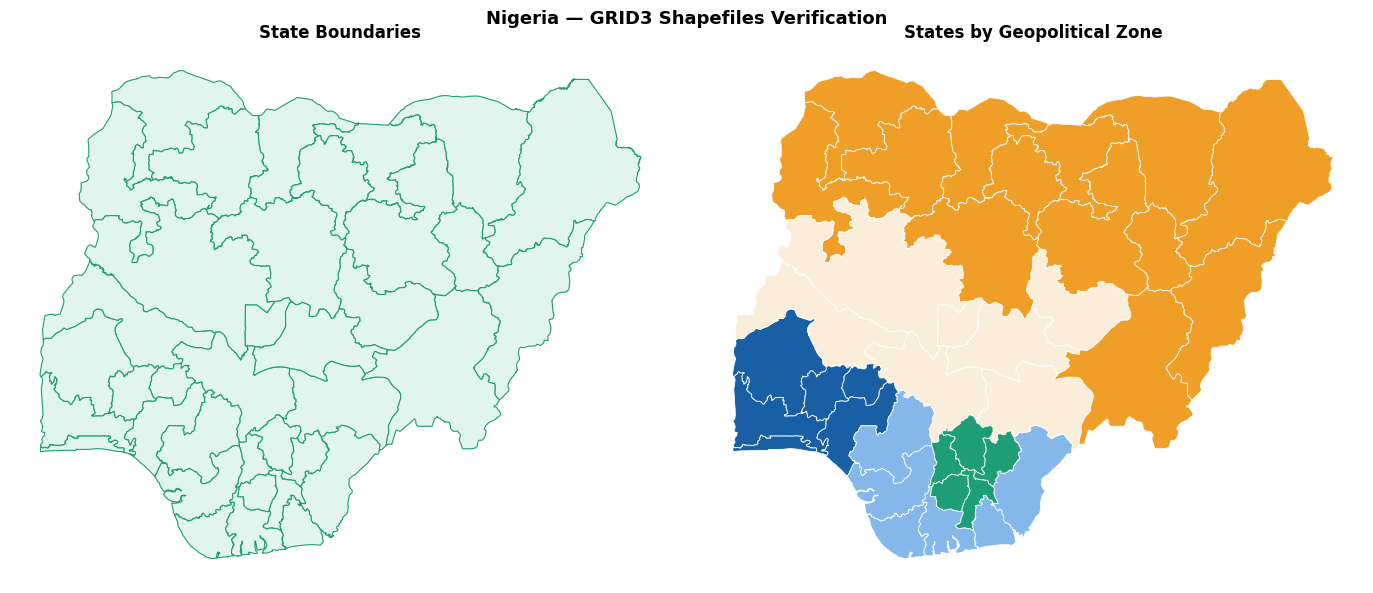


  ✅ Shapefile map saved → data/raw/shapefile_verification.png


In [2]:
from src.etl.extract import extract_shapefiles

print('Loading shapefiles...')
shapefiles = extract_shapefiles()

if not shapefiles:
    print('⚠️  No shapefiles found in data/shapefiles/')
    print('   Download from grid3.org and place nigeria_states.shp there')
else:
    for name, gdf in shapefiles.items():
        print(f'\n  ✅ {name}')
        print(f'     Features  : {len(gdf)}')
        print(f'     CRS       : {gdf.crs}')
        print(f'     EPSG:4326 : {gdf.crs.to_epsg() == 4326}')
        print(f'     Columns   : {list(gdf.columns)}')
        print(f'     Geometry  : {gdf.geom_type.unique()}')
        print(f'     Bounds    : {gdf.total_bounds.round(2)}')
        display(gdf.drop(columns=['geometry']).head(3))

    # Quick plot to visually verify geometry is correct
    if 'states' in shapefiles:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Left: plain boundary plot
        shapefiles['states'].plot(
            ax=axes[0], color='#E1F5EE',
            edgecolor='#1D9E75', linewidth=0.8
        )
        axes[0].set_title('State Boundaries', fontweight='bold')
        axes[0].axis('off')

        # Right: colour by geopolitical zone if zone column exists
        from src.utils.state_maps import GEOPOLITICAL_ZONES, normalise_state_name
        gdf_plot = shapefiles['states'].copy()

        # Find state name column
        name_col = next(
            (c for c in gdf_plot.columns
             if any(k in c.lower() for k in ['statename','state','name','adm1'])),
            None
        )
        if name_col:
            gdf_plot['canonical'] = gdf_plot[name_col].apply(normalise_state_name)
            gdf_plot['zone'] = gdf_plot['canonical'].map(GEOPOLITICAL_ZONES)
            zone_colours = {
                'North-East':'#EF9F27','North-West':'#EF9F27',
                'North-Central':'#FAEEDA',
                'South-West':'#185FA5','South-South':'#85B7EB',
                'South-East':'#1D9E75'
            }
            gdf_plot['colour'] = gdf_plot['zone'].map(zone_colours).fillna('#cccccc')
            gdf_plot.plot(ax=axes[1], color=gdf_plot['colour'],
                          edgecolor='white', linewidth=0.6)
            axes[1].set_title('States by Geopolitical Zone', fontweight='bold')
            axes[1].axis('off')

        plt.suptitle('Nigeria — GRID3 Shapefiles Verification',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(
            Paths.raw / 'shapefile_verification.png',
            dpi=150, bbox_inches='tight'
        )
        plt.show()
        print('\n  ✅ Shapefile map saved → data/raw/shapefile_verification.png')

## 9. Full Extraction Run

Run all extractors together in dependency order and produce a  
summary table — exactly what the ETL pipeline does at the  
Extract stage.

In [4]:
from src.etl.extract import (
    extract_ncdc_pdfs,
    extract_who_data,
    extract_nasa_rainfall,
    extract_health_facilities,
    extract_population,
    extract_shapefiles,
)

print('Running all extractors...')
print('='*55)

extraction_results = {}
start = time.perf_counter()

# NCDC PDFs — one per disease
for disease_name, folder_key in Diseases.pdf_folder_map.items():
    folder = Paths.raw / 'ncdc_pdfs' / folder_key
    df_ = extract_ncdc_pdfs(folder, disease_name)
    extraction_results[f'NCDC {disease_name}'] = df_

# Other sources (all use cache — instant if already fetched above)
extraction_results['WHO GHO']          = extract_who_data()
extraction_results['NASA Rainfall']    = extract_nasa_rainfall()
extraction_results['Health Facilities']= extract_health_facilities()
extraction_results['Population']       = extract_population()

elapsed = time.perf_counter() - start

print(f'\nExtraction complete in {elapsed:.1f}s')
print(f'\n  {"Source":<28} {"Status":<10} {"Rows":>8}')
print(f'  {"-"*28} {"-"*10} {"-"*8}')

total_rows = 0
for name, df_ in extraction_results.items():
    status = '✅ OK' if not df_.empty else '⚠️  MISSING'
    rows   = len(df_) if not df_.empty else 0
    total_rows += rows
    print(f'  {name:<28} {status:<10} {rows:>8,}')

print(f'  {"─"*28} {"─"*10} {"─"*8}')
print(f'  {"TOTAL":<28} {"":<10} {total_rows:>8,}')

# Shapefiles (GeoDataFrame — not a DataFrame, shown separately)
shapefiles = extract_shapefiles()
print(f'\n  Shapefiles loaded : {len(shapefiles)} ({list(shapefiles.keys())})')
print()
print('  ➡️  All raw data ready for transform.py')

Running all extractors...
2026-06-09 16:13:03 | INFO     | src.etl.extract | NCDC Cholera: loaded 1089 rows from cache
2026-06-09 16:13:03 | INFO     | src.etl.extract | NCDC Lassa Fever: loaded 4040 rows from cache
2026-06-09 16:13:03 | INFO     | src.etl.extract | NCDC Mpox: loaded 695 rows from cache
2026-06-09 16:13:04 | INFO     | src.etl.extract | NCDC Meningitis: loaded 201 rows from cache
2026-06-09 16:13:04 | INFO     | src.etl.extract | NCDC Yellow Fever: loaded 772 rows from cache
2026-06-09 16:13:04 | INFO     | src.etl.extract | WHO: loaded 45 rows from cache
2026-06-09 16:13:04 | INFO     | src.etl.extract | Rainfall: loaded 4440 rows from cache

Extraction complete in 1.0s

  Source                       Status         Rows
  ---------------------------- ---------- --------
  NCDC Cholera                 ✅ OK          1,089
  NCDC Lassa Fever             ✅ OK          4,040
  NCDC Mpox                    ✅ OK            695
  NCDC Meningitis              ✅ OK            

## 10. Summary — What to Expect from Each Source

In [5]:
from datetime import datetime
print('='*60)
print('  extract.py — FUNCTION REFERENCE SUMMARY')
print('='*60)
print(f'  Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print()

reference = [
    ('extract_ncdc_pdfs()', 'NCDC PDFs',   'Structured parsers per disease, 5 strategies'),
    ('extract_who_data()',  'WHO GHO API', 'Auto-fetched, annual cholera cases+deaths'),
    ('extract_nasa_rainfall()','NASA API', '~2min, -999 fill values, 12×N rows/state'),
    ('extract_health_facilities()','HDX CSV','Lat/lon coords, varies by download version'),
    ('extract_population()', 'NBS/WorldPop','Excel file, find pop column heuristically'),
    ('extract_shapefiles()', 'GRID3 .shp', 'GeoDataFrame, auto-reproject to WGS84'),
]

print(f'  {"Function":<32} {"Source":<14} Notes')
print(f'  {"-"*32} {"-"*14} {"-"*30}')
for func, source, note in reference:
    print(f'  {func:<32} {source:<14} {note}')

print()
print('  Key design principles:')
print('  • force_download=False  → use cache if available')
print('  • force_download=True   → always re-fetch/re-extract')
print('  • Empty DataFrame       → source unavailable (logged, not raised)')
print('  • _source_file column   → provenance on every row')
print()
print('  ➡️  Next: run transform.py to clean all this raw data')
print('='*60)

  extract.py — FUNCTION REFERENCE SUMMARY
  Generated: 2026-06-09 16:14

  Function                         Source         Notes
  -------------------------------- -------------- ------------------------------
  extract_ncdc_pdfs()              NCDC PDFs      Structured parsers per disease, 5 strategies
  extract_who_data()               WHO GHO API    Auto-fetched, annual cholera cases+deaths
  extract_nasa_rainfall()          NASA API       ~2min, -999 fill values, 12×N rows/state
  extract_health_facilities()      HDX CSV        Lat/lon coords, varies by download version
  extract_population()             NBS/WorldPop   Excel file, find pop column heuristically
  extract_shapefiles()             GRID3 .shp     GeoDataFrame, auto-reproject to WGS84

  Key design principles:
  • force_download=False  → use cache if available
  • force_download=True   → always re-fetch/re-extract
  • Empty DataFrame       → source unavailable (logged, not raised)
  • _source_file column   → provenance 